# Avaliação do Modelo — Credit Scoring Home Credit

> **Este notebook lê a rodada canônica de `artifacts/`.** Ele não recria o split
> nem re-pontua a base: os scores de todos os clientes estão em
> `artifacts/scores.parquet`, gravados pelo próprio `Model/train.py`.
>
> É essa dependência que garante que notebook, API e documentos não possam
> divergir. A versão anterior recriava o `train_test_split` por conta própria —
> e foi assim que dois conjuntos de métricas passaram a circular ao mesmo tempo.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'Model' else Path.cwd()
ART = ROOT / 'artifacts'

import sys; sys.path.insert(0, str(ROOT))
from Model.metrics_lib import (auc_bootstrap_ci, brier_score, confusion_at,
                               cost_at, derived_metrics, decile_table,
                               ks_statistic, threshold_sweep)

metrics = json.loads((ART / 'metrics.json').read_text())
curves = json.loads((ART / 'curves.json').read_text())
fairness = json.loads((ART / 'fairness.json').read_text())
importance = json.loads((ART / 'feature_importance.json').read_text())
scores = pd.read_parquet(ART / 'scores.parquet')
bundle = joblib.load(ART / 'model.joblib')

run = metrics['run']
print(f"Rodada {run['run_id']} ({run['tag']}) — treinada em {run['trained_at']}")
print(f"{run['n_rows']:,} clientes x {run['n_features']:,} features".replace(',', '.'))
print(f"Splits: treino {run['n_train']:,} | validacao {run['n_valid']:,} | "
      f"teste {run['n_test']:,}".replace(',', '.'))

Rodada 20260823-211811-d73d85c (v3-calibrado) — treinada em 2026-08-23T21:18:11-03:00
307.511 clientes x 1.018 features
Splits: treino 153.755 | validacao 61.502 | teste 61.503


## 1. O conjunto de teste

Vem rotulado do próprio treino — não há split para reconstruir.

In [2]:
teste = scores[scores.split == 'test']
y_test = teste.y_true.to_numpy()
score = teste.proba_champion.to_numpy()

print(f'{len(teste):,} clientes no teste'.replace(',', '.'))
print(f'Inadimplencia real: {y_test.mean():.2%}')
print(f'Score medio:        {score.mean():.4f}   <- num modelo calibrado, ~= a inadimplencia')
print(f'AUC:                {metrics["champion"]["auc"]:.4f}')
print(f'KS:                 {ks_statistic(y_test, score):.4f}')

61.503 clientes no teste
Inadimplencia real: 8.07%
Score medio:        0.0805   <- num modelo calibrado, ~= a inadimplencia
AUC:                0.7871
KS:                 0.4342


## 2. Curvas ROC e Precision-Recall

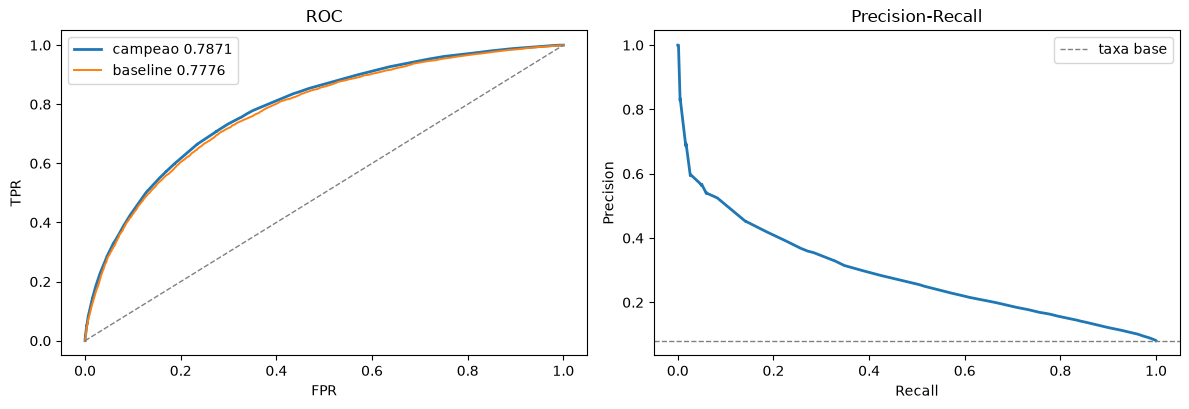

In [3]:
from sklearn.metrics import precision_recall_curve, roc_curve

fpr, tpr, _ = roc_curve(y_test, score)
prec, rec, _ = precision_recall_curve(y_test, score)
base_pts = curves['baseline']['test']['roc']['points']

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(fpr, tpr, lw=2, label=f"campeao {metrics['champion']['auc']:.4f}")
ax[0].plot([p['fpr'] for p in base_pts], [p['tpr'] for p in base_pts], lw=1.4,
           label=f"baseline {metrics['baseline']['auc']:.4f}")
ax[0].plot([0, 1], [0, 1], '--', c='gray', lw=1)
ax[0].set_title('ROC'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
ax[1].plot(rec, prec, lw=2)
ax[1].axhline(y_test.mean(), ls='--', c='gray', lw=1, label='taxa base')
ax[1].set_title('Precision-Recall'); ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. KS e tabela de decis

A tabela de decis é a linguagem que uma mesa de crédito reconhece: a carteira
ordenada do pior para o melhor decil de risco.

KS = 0.4342


,decile,n,avg_score,events,event_rate,lift,cum_event_pct,ks
0,1,6150,0.2990,1861,0.3026,3.7484,0.3748,0.2990
1,2,6150,0.1496,964,0.1567,1.9417,0.5690,0.4014
2,3,6150,0.1090,643,0.1046,1.2951,0.6985,0.4335
3,4,6151,0.0818,446,0.0725,0.8982,0.7883,0.4224
4,5,6150,0.0545,326,0.0530,0.6566,0.8540,0.3851
5,6,6150,0.0330,231,0.0376,0.4653,0.9005,0.3269
6,7,6151,0.0301,189,0.0307,0.3806,0.9386,0.2595
7,8,6150,0.0242,147,0.0239,0.2961,0.9682,0.1830
8,9,6150,0.0165,98,0.0159,0.1974,0.9879,0.0956
9,10,6151,0.0077,60,0.0098,0.1208,1.0000,0.0000


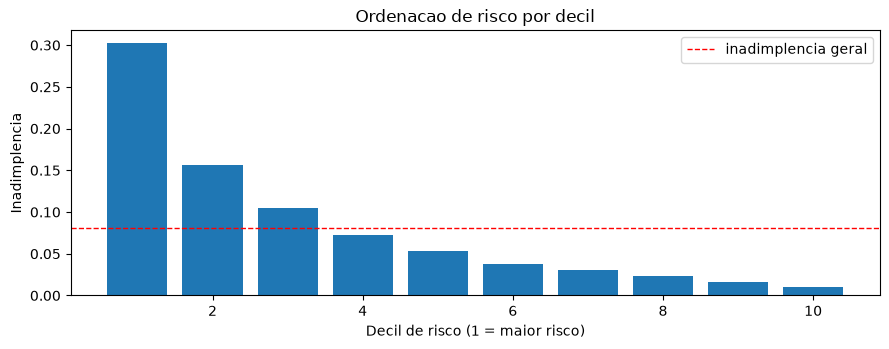

In [4]:
decis = pd.DataFrame(decile_table(y_test, score))
print(f'KS = {ks_statistic(y_test, score):.4f}')
display(decis[['decile', 'n', 'avg_score', 'events', 'event_rate', 'lift',
               'cum_event_pct', 'ks']].round(4))

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(decis.decile, decis.event_rate)
ax.axhline(y_test.mean(), ls='--', c='r', lw=1, label='inadimplencia geral')
ax.set_xlabel('Decil de risco (1 = maior risco)'); ax.set_ylabel('Inadimplencia')
ax.set_title('Ordenacao de risco por decil'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Calibração

O ponto mais importante desta rodada. Com `is_unbalance=true` o LightGBM produz
um score que **ordena bem mas não é P(inadimplência) real** — o corte ótimo caía
em 0,47, um número que não se pode defender como probabilidade.

A regressão isotônica, ajustada numa fatia exclusiva de calibração, corrige isso
**sem alterar a ordenação** (é monotônica).

Metodo: isotonic. ajustado em 30.751 clientes
Brier: 0.1668 -> 0.0658
AUC:   0.7871 -> 0.7868  (nao muda: isotonica e monotonica)


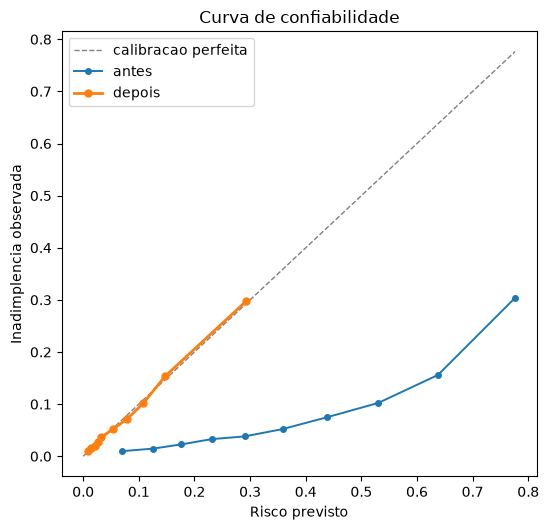

In [5]:
cal = metrics.get('calibrated', {})
pts = curves['champion']['test']['calibration']
cru = curves['champion']['test'].get('calibration_raw', [])

if cal:
    print(f"Metodo: {cal['method']}, ajustado em {cal['n_calib']:,} clientes".replace(',', '.'))
    print(f"Brier: {cal['brier_before']:.4f} -> {cal['brier']:.4f}")
    print(f"AUC:   {metrics['champion']['auc']:.4f} -> {cal['auc']:.4f}  (nao muda: isotonica e monotonica)")

fig, ax = plt.subplots(figsize=(5.6, 5.4))
lim = max(max(p['mean_predicted'] for p in pts + cru),
          max(p['observed_rate'] for p in pts + cru))
ax.plot([0, lim], [0, lim], '--', c='gray', lw=1, label='calibracao perfeita')
if cru:
    ax.plot([p['mean_predicted'] for p in cru], [p['observed_rate'] for p in cru],
            'o-', lw=1.4, ms=4, label='antes')
ax.plot([p['mean_predicted'] for p in pts], [p['observed_rate'] for p in pts],
        'o-', lw=2, ms=5, label='depois')
ax.set_xlabel('Risco previsto'); ax.set_ylabel('Inadimplencia observada')
ax.set_title('Curva de confiabilidade'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Do score à decisão: a régua de custo

O corte não foi escolhido "no olho": é o que minimiza o custo esperado, dado que
aprovar um mau pagador custa 10× negar um bom pagador.

In [6]:
b = metrics['business']
thr = b['threshold']
cm = confusion_at(y_test, score, thr)
d = derived_metrics(cm)

print(f"Threshold de negocio: {thr:.2f}")
print(f"Matriz de confusao [[TN FP] [FN TP]]:")
print(np.array([[cm['tn'], cm['fp']], [cm['fn'], cm['tp']]]))
print(f"\nTaxa de aprovacao:              {d['approval_rate']:.1%}")
print(f"Inadimplencia da carteira APROVADA: {d['default_rate_approved']:.2%}")
print(f"Inadimplencia da carteira NEGADA:   {d['default_rate_denied']:.2%}")
print(f"Recall na classe inadimplente:      {d['recall']:.1%}")

# Sensibilidade: e se a razao de custo fosse outra?
linhas = []
for fn, fp in [(1, 1), (5, 1), (10, 1), (20, 1), (50, 1)]:
    pts_ = threshold_sweep(y_test, score, fn, fp, n_points=99)
    melhor = min(pts_, key=lambda r: r['cost'])
    linhas.append({'custo FN:FP': f'{fn}:{fp}', 'corte otimo': melhor['threshold'],
                   'aprovacao': melhor['approval_rate'],
                   'inadimp. aprovada': melhor['default_rate_approved']})
display(pd.DataFrame(linhas).round(4))

Threshold de negocio: 0.09
Matriz de confusao [[TN FP] [FN TP]]:
[[40992 15546]
 [ 1448  3517]]

Taxa de aprovacao:              69.0%
Inadimplencia da carteira APROVADA: 3.41%
Inadimplencia da carteira NEGADA:   18.45%
Recall na classe inadimplente:      70.8%


,custo FN:FP,corte otimo,aprovacao,inadimp. aprovada
0,1:1,0.45,0.9930,0.0773
1,5:1,0.15,0.8433,0.0479
2,10:1,0.10,0.6901,0.0341
3,20:1,0.05,0.5226,0.0246
4,50:1,0.02,0.2320,0.0133


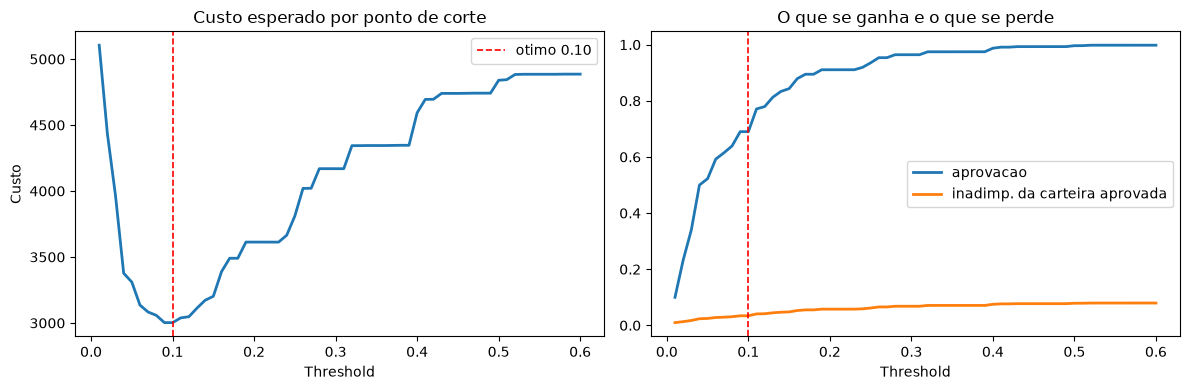

In [7]:
sweep = pd.DataFrame(threshold_sweep(y_test, score, b['cost_false_negative'],
                                     b['cost_false_positive'], n_points=99))
foco = sweep[sweep.threshold <= 0.6]
otimo = foco.loc[foco.cost.idxmin()]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(foco.threshold, foco.cost, lw=2)
ax[0].axvline(otimo.threshold, ls='--', c='r', lw=1.2,
              label=f'otimo {otimo.threshold:.2f}')
ax[0].set_title('Custo esperado por ponto de corte')
ax[0].set_xlabel('Threshold'); ax[0].set_ylabel('Custo'); ax[0].legend()
ax[1].plot(foco.threshold, foco.approval_rate, lw=2, label='aprovacao')
ax[1].plot(foco.threshold, foco.default_rate_approved, lw=2,
           label='inadimp. da carteira aprovada')
ax[1].axvline(otimo.threshold, ls='--', c='r', lw=1.2)
ax[1].set_title('O que se ganha e o que se perde'); ax[1].set_xlabel('Threshold')
ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Importância das variáveis

> ⚠️ **Correção em relação à versão anterior deste notebook:** ele plotava
> `model.feature_importances_` com o título "gain", mas o padrão do
> `LGBMClassifier` é `split` (número de vezes que a variável foi usada para
> partir um nó). São coisas diferentes, e uma banca de crédito conhece a
> diferença. Aqui as duas aparecem, cada uma com o rótulo certo.

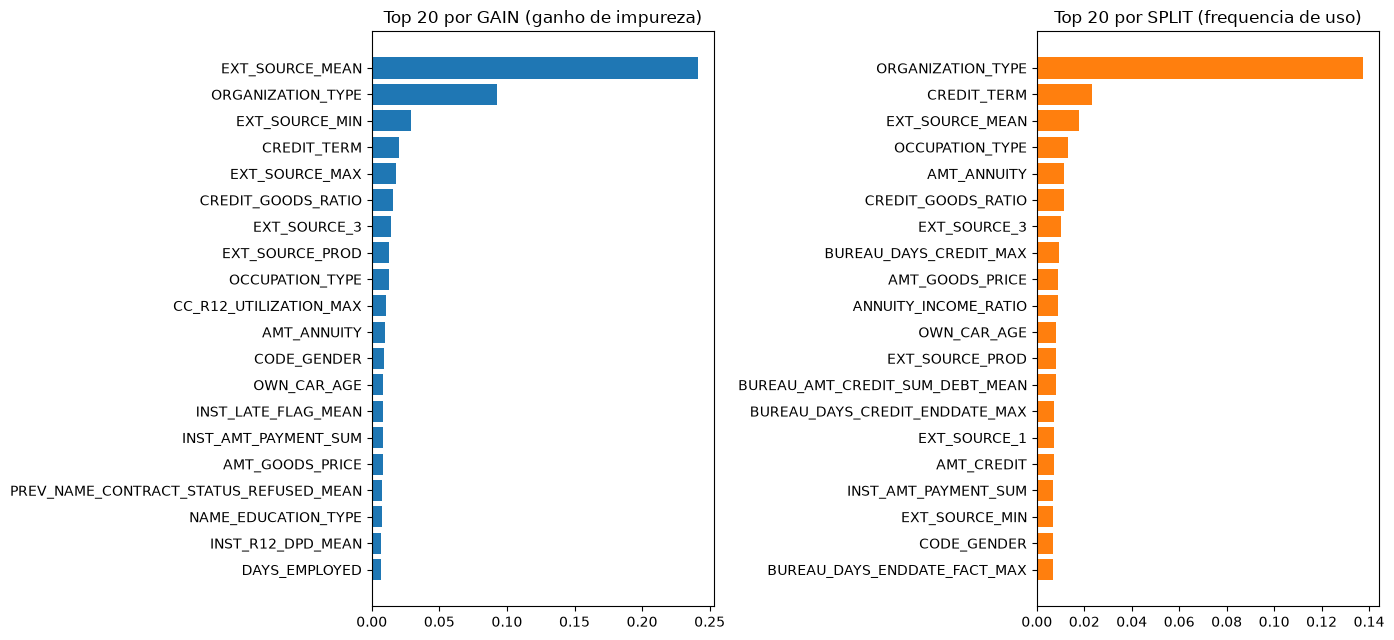

A ABT das 9 tabelas valeu a pena? Importancia por tabela de origem:


,fracao do ganho
application,60.3%
PREV,11.9%
INST,10.8%
BUREAU,7.6%
POS,4.2%
CC,3.7%
BUREAU_BALANCE,1.5%


As tabelas relacionais respondem por 39.7% da importancia.


In [8]:
gain = pd.DataFrame(importance['gain']).head(20)
split_ = pd.DataFrame(importance['split']).head(20)

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
ax[0].barh(gain.feature[::-1], gain.importance_pct[::-1])
ax[0].set_title('Top 20 por GAIN (ganho de impureza)')
ax[1].barh(split_.feature[::-1], split_.importance_pct[::-1], color='tab:orange')
ax[1].set_title('Top 20 por SPLIT (frequencia de uso)')
plt.tight_layout(); plt.show()

print('A ABT das 9 tabelas valeu a pena? Importancia por tabela de origem:')
origem = pd.Series(importance['by_source']).sort_values(ascending=False)
display(origem.to_frame('fracao do ganho').style.format('{:.1%}'))
relacional = origem.drop('application', errors='ignore').sum()
print(f'As tabelas relacionais respondem por {relacional:.1%} da importancia.')

## 7. Explicabilidade — SHAP

O SHAP explica o modelo **cru** (a árvore). Como a calibração isotônica é
monotônica, a ordem e o sinal das contribuições continuam valendo.

/home/victor/workspace/fia_tcc/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


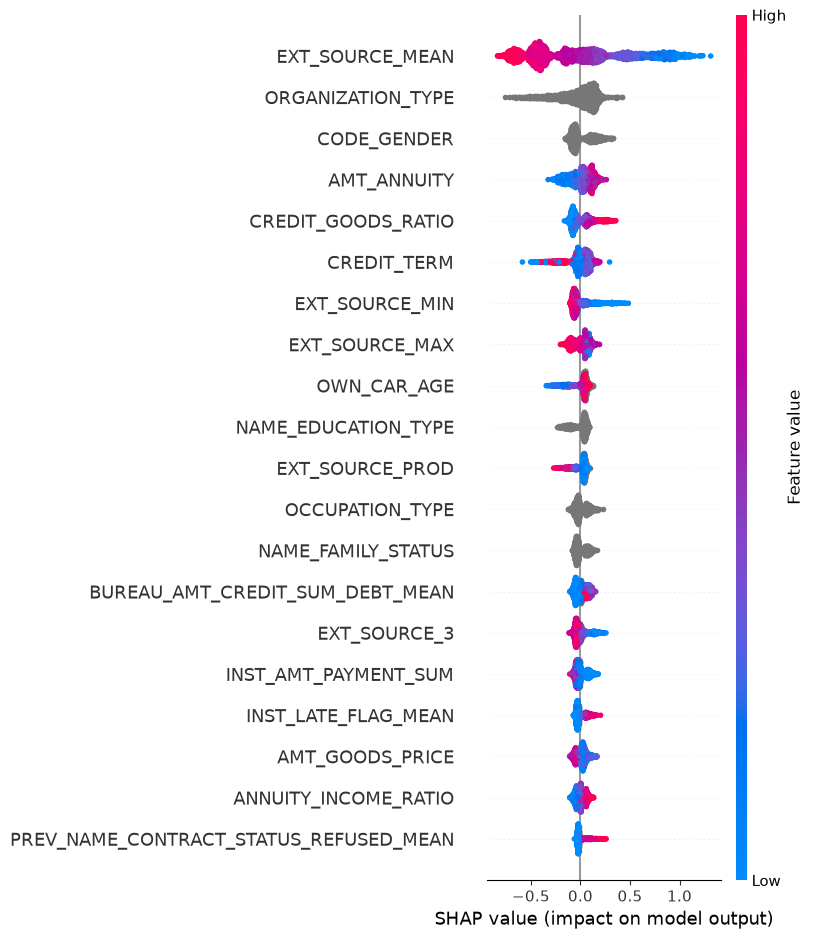

In [9]:
import shap

abt = pd.read_parquet(ROOT / 'Dados' / 'abt.parquet')
abt = abt[abt.SK_ID_CURR.isin(teste.SK_ID_CURR)]
X = abt[bundle['feature_names']].copy()
for c in bundle['categorical_features']:
    X[c] = pd.Categorical(X[c], categories=bundle['cat_categories'][c])
amostra = X.sample(2000, random_state=42)

explainer = shap.TreeExplainer(bundle['model'], feature_perturbation='tree_path_dependent')
sv = explainer.shap_values(amostra)
if isinstance(sv, list):
    sv = sv[1] if len(sv) == 2 else sv[0]
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, -1]
shap.summary_plot(sv, amostra, max_display=20)

## 8. Onde o modelo é confiável — e onde não é

**A diferença central em relação à versão anterior:** cada AUC de segmento vem
acompanhado de um **intervalo de confiança bootstrap**.

Sem o intervalo não se distingue fraqueza real de ruído amostral — e essa
distinção muda a conclusão do trabalho. Um grupo só conta como fraqueza real
quando o **topo do seu IC fica abaixo do piso do IC geral**.

In [10]:
geral = fairness['overall']
print(f"AUC geral: {geral['auc']:.4f}  IC 95% [{geral['ci_low']:.4f} - {geral['ci_high']:.4f}]")
print(f"n = {geral['n']:,}  |  Brier = {geral['brier']:.4f}".replace(',', '.'))

linhas = []
for dim, grupos in fairness['dimensions'].items():
    for g in grupos:
        linhas.append({
            'dimensao': dim, 'grupo': g['group'], 'n': g['n'],
            'AUC': g['auc'], 'IC inf': g['ci_low'], 'IC sup': g['ci_high'],
            'fraqueza real': g['ci_high'] < geral['ci_low'],
            'aprovacao': g['approval_rate'], 'inadimp. real': g['default_rate'],
        })
seg = pd.DataFrame(linhas)
display(seg.round(4))

AUC geral: 0.7868  IC 95% [0.7806 - 0.7935]
n = 61.503  |  Brier = 0.0658


,dimensao,grupo,n,AUC,IC inf,IC sup,fraqueza real,aprovacao,inadimp. real
0,gender,F,40561,0.7795,0.7709,0.7886,False,0.7343,0.0699
1,gender,M,20940,0.7872,0.7778,0.7963,False,0.6043,0.1017
2,age_band,25-35,14304,0.7834,0.7716,0.7947,False,0.5721,0.1055
3,age_band,35-45,16912,0.7899,0.7779,0.8015,False,0.6909,0.0824
4,age_band,45-55,14041,0.7942,0.7805,0.8063,False,0.7351,0.0739
5,age_band,55-65,12166,0.7465,0.7281,0.7672,True,0.7992,0.0561
6,age_band,65+,1725,0.7631,0.7084,0.8100,False,0.8991,0.0371
7,age_band,<25,2355,0.7319,0.7012,0.7597,True,0.4149,0.1180
8,thin_file,com histórico de bureau,52727,0.7878,0.7808,0.7950,False,0.7109,0.0773
9,thin_file,thin-file (sem bureau),8776,0.7745,0.7577,0.7899,False,0.5649,0.1014


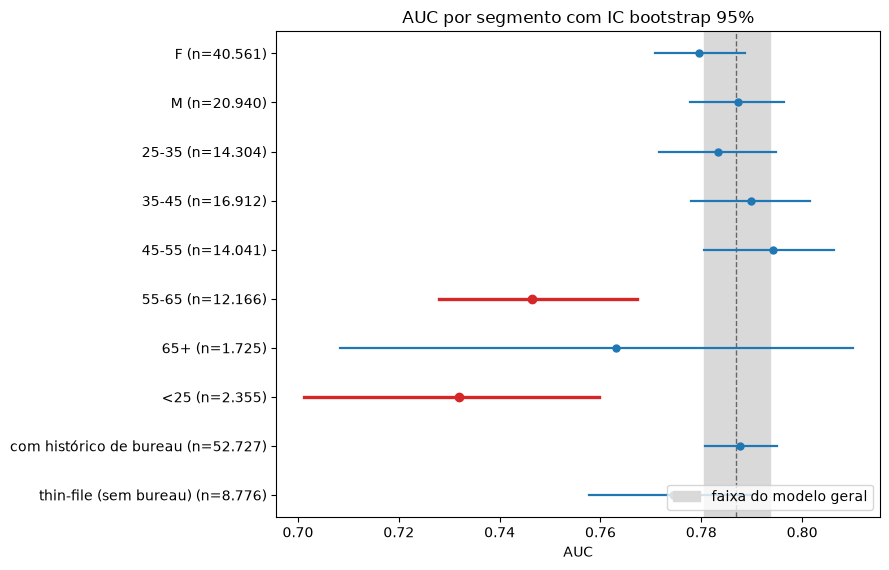

Fraquezas REAIS (IC nao sobrepoe o geral): ['55-65', '<25']
Demais diferencas estao dentro do ruido amostral.


In [11]:
fig, ax = plt.subplots(figsize=(9, 0.42 * len(seg) + 1.6))
ax.axvspan(geral['ci_low'], geral['ci_high'], color='0.85',
           label='faixa do modelo geral')
ax.axvline(geral['auc'], ls='--', c='0.4', lw=1)

for i, r in seg.iloc[::-1].reset_index(drop=True).iterrows():
    cor = 'tab:red' if r['fraqueza real'] else 'tab:blue'
    ax.plot([r['IC inf'], r['IC sup']], [i, i], lw=2.4 if r['fraqueza real'] else 1.6, c=cor)
    ax.plot(r['AUC'], i, 'o', ms=6 if r['fraqueza real'] else 5, c=cor)

rot = seg.iloc[::-1].apply(lambda r: f"{r['grupo']} (n={r['n']:,})".replace(',', '.'), axis=1)
ax.set_yticks(range(len(seg))); ax.set_yticklabels(rot)
ax.set_xlabel('AUC'); ax.set_title('AUC por segmento com IC bootstrap 95%')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

reais = seg[seg['fraqueza real']]
print('Fraquezas REAIS (IC nao sobrepoe o geral):',
      list(reais.grupo) if len(reais) else 'nenhuma')
print('Demais diferencas estao dentro do ruido amostral.')

## 9. O que foi consertado — e o que não foi

Três rodadas, medidas contra o mesmo conjunto de teste, com regra de aceite
declarada antes: um conserto fica se melhorar o segmento-alvo sem piorar o geral.

In [12]:
log = json.loads((ART / 'improvement_log.json').read_text())
rodadas = [r for r in log['runs'] if not r.get('sample')]
evol = pd.DataFrame([{'rodada': r['tag'], 'features': r['n_features'],
                      'AUC': r['auc'], 'KS': r['ks'], 'Brier': r['brier'],
                      'corte': r['threshold'], 'aprovacao': r['approval_rate']}
                     for r in rodadas])
display(evol.round(4))

primeira, ultima = rodadas[0], rodadas[-1]
linhas = []
for dim, grupos in ultima['segments'].items():
    for nome, novo in grupos.items():
        velho = primeira['segments'].get(dim, {}).get(nome)
        if not velho or velho['auc'] is None or novo['auc'] is None:
            continue
        linhas.append({'dimensao': dim, 'grupo': nome, 'n': novo['n'],
                       'AUC antes': velho['auc'], 'AUC depois': novo['auc'],
                       'delta': novo['auc'] - velho['auc']})
antes_depois = pd.DataFrame(linhas).sort_values('delta')
display(antes_depois.round(4))

,rodada,features,AUC,KS,Brier,corte,aprovacao
0,v1-baseline,471,0.7846,0.4349,0.1639,0.47,0.6914
1,v2-abt-corrigida,1018,0.7880,0.4402,0.1649,0.50,0.7184
2,v3-calibrado,1018,0.7871,0.4354,0.0658,0.09,0.6865


,dimensao,grupo,n,AUC antes,AUC depois,delta
6,age_band,65+,1725,0.7843,0.7631,-0.0212
7,age_band,<25,2355,0.7364,0.7319,-0.0045
0,gender,F,40561,0.7783,0.7795,0.0011
9,thin_file,thin-file (sem bureau),8776,0.7733,0.7745,0.0012
2,age_band,25-35,14304,0.7820,0.7834,0.0014
8,thin_file,com histórico de bureau,52727,0.7854,0.7878,0.0023
3,age_band,35-45,16912,0.7868,0.7899,0.0030
5,age_band,55-65,12166,0.7430,0.7465,0.0035
1,gender,M,20940,0.7834,0.7872,0.0038
4,age_band,45-55,14041,0.7896,0.7942,0.0046


## Diagnóstico crítico (Results / Governança)

### Overfitting — controlado

AUC treino → validação → teste: o gap treino→validação é esperado com mais de
mil variáveis. O que importa é que **validação e teste empatam** — se houvesse
overfitting real, o teste despencaria abaixo da validação.

### Gênero — não há viés

O poder de ordenação é praticamente idêntico entre os grupos. A aprovação menor
para homens acompanha a inadimplência real observada. **Diferença de aprovação
não é viés**: o modelo discrimina risco, não pessoas.

### Idade — fraqueza real, e assumida

Nos dois extremos o IC não sobrepõe o geral. É limitação técnica: o modelo
**enxerga pior** nesses grupos, e isso não é reflexo do risco real.

### Thin-file — a diferença NÃO está estabelecida

Versões anteriores deste trabalho afirmavam que thin-file era fraqueza
comprovada. Com intervalo de confiança, **não é** — o IC sobrepõe o geral.
Assumir isso é mais forte que sustentar um número que não se comprova.

### O que não foi resolvido

As correções (categóricas da ABT, scores externos combinados, calibração)
melhoraram o modelo geral e a maioria dos segmentos, mas **a faixa abaixo de
25 anos praticamente não se moveu**. É o grupo com menos histórico por
definição, e histórico é o insumo que falta.

A resposta é de processo, não de modelagem: **régua de três faixas**, com a
faixa cinza dobrada nos segmentos de baixa confiança medida, encaminhando esses
casos a análise humana com o relatório SHAP.

### Monitoramento sugerido

PSI das variáveis de entrada, drift do score, AUC em janela móvel, taxa de
aprovação e inadimplência observada, e AUC segmentado recalculado periodicamente.